# Proceso de Limpieza de Datos
Este notebook estará dedicado principalmente a la limpieza y preparación de los datos para la posterior construcción del modelo

## Librerías

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

In [5]:
original_data = pd.read_csv("../../data-base/ecommerce_customer_churn_dataset.csv")
original_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null 

## Eliminar datos con baja calidad

Eliminamos registros con Edad mayor a 100

In [8]:
dataset_to_clean = original_data.copy()
dataset_to_clean = dataset_to_clean[dataset_to_clean['Age'] <= 100]
print(f"Registros después de eliminar registros con edad mayor a 100: {dataset_to_clean.shape[0]}")

Registros después de eliminar registros con edad mayor a 100: 47485


Eliminamos registros duplicados

In [9]:
dataset_to_clean.drop_duplicates(inplace=True)
print(f"Registros después de eliminar duplicados ➡️ {dataset_to_clean.shape[0]}")

Registros después de eliminar duplicados ➡️ 47485


## Manejo de Datos Nulos y Outliers

### Outliers

Eliminamos Clientes sin compras o valores negativos (dato atípico)

In [10]:
dataset_without_outliers = dataset_to_clean.loc[(dataset_to_clean['Total_Purchases'] > 0)] # Clientes con al menos una compra

print("Registros antes de eliminar clientes sin compra:", dataset_to_clean.shape[0])
print("Registros después de eliminar clientes sin compra:", dataset_without_outliers.shape[0])

Registros antes de eliminar clientes sin compra: 47485
Registros después de eliminar clientes sin compra: 47440


Eliminamos Clientes con una tasa de abandono del carrito mayor a 100

In [11]:
print("Registros antes de eliminar clientes con porcentaje de abandono de carrito mayor a 100:", dataset_without_outliers.shape[0])

dataset_without_outliers = dataset_without_outliers.loc[~(dataset_without_outliers['Cart_Abandonment_Rate'] > 100)] # Clientes con un cart abandonment rate mayor a 100
print("Registros después de eliminar clientes con porcentaje de abandono de carrito mayor a 100:", dataset_without_outliers.shape[0])

Registros antes de eliminar clientes con porcentaje de abandono de carrito mayor a 100: 47440
Registros después de eliminar clientes con porcentaje de abandono de carrito mayor a 100: 47412


Eliminamos Clientes con AOV atípicos

Para que nuestro análisis refleje el comportamiento real de la mayoría, filtraremos los pedidos con valores fuera de lo común que podrían distorsionar los resultados generales.

In [12]:
def eliminar_outliers_iqr(df, columna):
    q1 = df[columna].quantile(0.25)
    q3 = df[columna].quantile(0.75)
    iqr = q3 - q1
    
    limite_inferior = q1 - (1.5 * iqr)
    limite_superior = q3 + (1.5 * iqr)
    
    # Filtrar el DataFrame
    df_filtrado = df[(df[columna] >= limite_inferior) & (df[columna] <= limite_superior)]
    return df_filtrado

In [13]:
print("Registros antes de eliminar atípicos por AOV:", dataset_without_outliers.shape[0])

dataset_without_outliers = eliminar_outliers_iqr(dataset_without_outliers, 'Average_Order_Value')
print("Registros antes de eliminar atípicos por AOV:", dataset_without_outliers.shape[0])

Registros antes de eliminar atípicos por AOV: 47412
Registros antes de eliminar atípicos por AOV: 46467


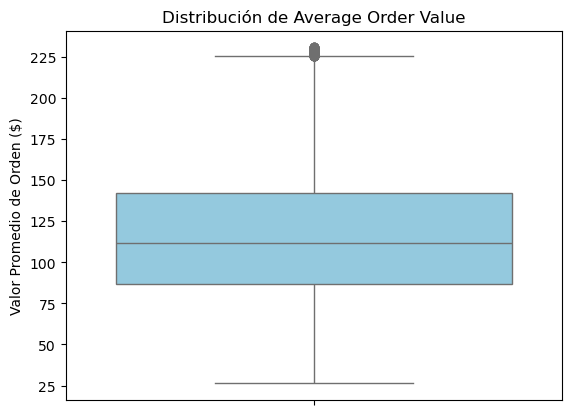

In [14]:
sns.boxplot(y=dataset_without_outliers['Average_Order_Value'], color="skyblue")

plt.title('Distribución de Average Order Value')
plt.ylabel('Valor Promedio de Orden ($)')
plt.show()

### Imputación de Nulos

In [15]:
imputer = SimpleImputer(strategy='mean')
columns_to_impute = dataset_without_outliers.select_dtypes(include=['int64','float64']).columns

dataset_without_outliers[columns_to_impute] = imputer.fit_transform(dataset_without_outliers[columns_to_impute])

dataset_without_outliers = dataset_without_outliers.reset_index(drop=True)

porcentaje_de_nulos = round((dataset_without_outliers.isnull().sum() / dataset_without_outliers.shape[0])*100,2)
porcentaje_de_nulos

Age                              0.0
Gender                           0.0
Country                          0.0
City                             0.0
Membership_Years                 0.0
Login_Frequency                  0.0
Session_Duration_Avg             0.0
Pages_Per_Session                0.0
Cart_Abandonment_Rate            0.0
Wishlist_Items                   0.0
Total_Purchases                  0.0
Average_Order_Value              0.0
Days_Since_Last_Purchase         0.0
Discount_Usage_Rate              0.0
Returns_Rate                     0.0
Email_Open_Rate                  0.0
Customer_Service_Calls           0.0
Product_Reviews_Written          0.0
Social_Media_Engagement_Score    0.0
Mobile_App_Usage                 0.0
Payment_Method_Diversity         0.0
Lifetime_Value                   0.0
Credit_Balance                   0.0
Churned                          0.0
Signup_Quarter                   0.0
dtype: float64

## Archivo Final

In [17]:
dataset_without_outliers.to_csv(r'../../data-base/clean_ecommerce_customer_churn_dataset.csv', index=False)